# 03 — Fit Signal PoC

This notebook creates the second signal layer for ReturnShield.

It does **not** train a prediction model. It converts observed fit, length, quality, and available review feedback from ModCloth / RentTheRunway into item-level signals that can later feed the mock cart and agent layers.

Output:

```text
data/processed/fit_signals.csv
```

Design rules:

- UCI Online Retail remains the main return/cancel label source.
- Fit data is not merged row-by-row with UCI users or transactions.
- Fit data is used only to create a separate size/fit signal layer.
- All generated numeric risk scores are in the `[0, 1]` range when the underlying signal exists.
- Higher score means stronger risk signal.
- Missing evidence is not treated as low risk.
- If an item has no evidence for an auxiliary signal family, that score stays missing and its reliability weight is 0.
- Low-coverage items with at least one observation are smoothed toward the global dataset rate.
- Smoothing prior strength is estimated from the observed item coverage distribution.
- Reliability is represented as a continuous weight, not a hardcoded threshold.
- Review-derived signals are exported only when review text exists. If the dataset version has no review text, review scores stay missing and `has_review_text = 0`.


## 1. Setup

The path setup works when the notebook is executed either from the repository root or from the `notebooks/` directory.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.6f}".format)


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "data").exists() or (path / "notebooks").exists():
            return path
    return current


BASE_DIR = find_project_root()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS = BASE_DIR / "outputs"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_RAW:", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)


BASE_DIR: C:\Users\monster\Desktop\returnshield-ai
DATA_RAW: C:\Users\monster\Desktop\returnshield-ai\data\raw
DATA_PROCESSED: C:\Users\monster\Desktop\returnshield-ai\data\processed


## 2. Load fit datasets

Expected locations:

```text
data/raw/clothing_fit/modcloth_final_data.json
data/raw/clothing_fit/renttherunway_final_data.json
```

ModCloth is closer to a standard purchase scenario. RentTheRunway can also be loaded, but the `source` column is always kept so that the two datasets are not silently mixed.


In [2]:
FIT_DATA_CANDIDATES = {
    "modcloth": [
        DATA_RAW / "clothing_fit" / "modcloth_final_data.json",
        DATA_RAW / "modcloth_final_data.json",
        BASE_DIR / "modcloth_final_data.json",
        Path("/mnt/data/modcloth_final_data.json"),
    ],
    "renttherunway": [
        DATA_RAW / "clothing_fit" / "renttherunway_final_data.json",
        DATA_RAW / "renttherunway_final_data.json",
        BASE_DIR / "renttherunway_final_data.json",
        Path("/mnt/data/renttherunway_final_data.json"),
    ],
}


EXPECTED_RAW_COLUMNS = {"item_id", "user_id", "fit"}


def _normalize_raw_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


def first_existing_path(paths):
    return next((path for path in paths if path.exists()), None)


def _normalized_columns(columns):
    return {_normalize_raw_column_name(col) for col in columns}


def _looks_like_fit_dataframe(df):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return False
    return EXPECTED_RAW_COLUMNS.issubset(_normalized_columns(df.columns))


def _records_to_dataframe(records):
    if len(records) == 1 and isinstance(records[0], list):
        records = records[0]
    if len(records) == 1 and isinstance(records[0], dict) and "root" in records[0]:
        root_value = records[0]["root"]
        if isinstance(root_value, list):
            records = root_value
    return pd.DataFrame(records)


def load_json_records(path):
    """Load JSON array, JSON-lines, or concatenated JSON-object files robustly."""
    candidate_readers = [
        lambda: pd.read_json(path, lines=True),
        lambda: pd.read_json(path),
    ]

    for reader in candidate_readers:
        try:
            candidate_df = reader()
            if _looks_like_fit_dataframe(candidate_df):
                return candidate_df
        except ValueError:
            pass

    # JSON-lines fallback.
    line_records = []
    line_parse_ok = True
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            try:
                line_records.append(json.loads(line))
            except json.JSONDecodeError:
                line_parse_ok = False
                line_records = []
                break

    if line_parse_ok and line_records:
        candidate_df = _records_to_dataframe(line_records)
        if _looks_like_fit_dataframe(candidate_df):
            return candidate_df

    # Concatenated-object or JSON-array fallback.
    text = Path(path).read_text(encoding="utf-8").strip()
    decoder = json.JSONDecoder()
    records = []
    idx = 0

    while idx < len(text):
        while idx < len(text) and text[idx].isspace():
            idx += 1
        if idx >= len(text):
            break
        obj, next_idx = decoder.raw_decode(text, idx)
        if isinstance(obj, list):
            records.extend(obj)
        else:
            records.append(obj)
        idx = next_idx

    candidate_df = _records_to_dataframe(records)
    if _looks_like_fit_dataframe(candidate_df):
        return candidate_df

    raise ValueError(f"Could not parse expected fit dataset columns from {path}")


loaded_frames = []

for source_name, paths in FIT_DATA_CANDIDATES.items():
    selected_path = first_existing_path(paths)
    if selected_path is None:
        print(f"{source_name}: file not found")
        continue

    source_df = load_json_records(selected_path)
    source_df["source"] = source_name
    loaded_frames.append(source_df)
    print(f"{source_name}: loaded {source_df.shape[0]:,} rows from {selected_path}")

if not loaded_frames:
    raise FileNotFoundError(
        "No fit dataset file was found. Place modcloth_final_data.json and/or "
        "renttherunway_final_data.json under data/raw/clothing_fit/."
    )

raw_fit_df = pd.concat(loaded_frames, ignore_index=True, sort=False)
print("Combined shape:", raw_fit_df.shape)
display(raw_fit_df.head())


modcloth: loaded 82,790 rows from C:\Users\monster\Desktop\returnshield-ai\data\raw\clothing_fit\modcloth_final_data.json
renttherunway: loaded 192,544 rows from C:\Users\monster\Desktop\returnshield-ai\data\raw\clothing_fit\renttherunway_final_data.json
Combined shape: (275334, 26)


,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text,source,bust size,weight,rating,rented for,body type,age,review_date
0,123373,29.000000,7,5.000000,d,38.000000,34.000000,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN,modcloth,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,123373,31.000000,13,3.000000,b,30.000000,36.000000,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN,modcloth,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,123373,30.000000,7,2.000000,b,NaN,32.000000,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.000000,NaN,NaN,NaN,modcloth,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,123373,NaN,21,5.000000,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN,modcloth,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.000000,b,NaN,36.000000,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN,modcloth,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Normalize columns

The raw datasets contain spaces and inconsistent naming conventions. This section standardizes the columns needed for signal generation.


In [3]:
def normalize_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


fit_df = raw_fit_df.copy()
fit_df.columns = [normalize_column_name(col) for col in fit_df.columns]

required_columns = ["item_id", "user_id", "fit"]
missing_required = [col for col in required_columns if col not in fit_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

optional_columns = [
    "category",
    "size",
    "quality",
    "length",
    "review_text",
    "review_summary",
    "source",
]

for col in optional_columns:
    if col not in fit_df.columns:
        fit_df[col] = np.nan

fit_df = fit_df[
    [
        "item_id",
        "user_id",
        "category",
        "size",
        "quality",
        "fit",
        "length",
        "review_text",
        "review_summary",
        "source",
    ]
].copy()

fit_df["item_id"] = fit_df["item_id"].astype(str)
fit_df["user_id"] = fit_df["user_id"].astype(str)
fit_df["fit"] = fit_df["fit"].astype(str).str.lower().str.strip()
fit_df["length"] = fit_df["length"].astype(str).str.lower().str.strip()
fit_df["category"] = fit_df["category"].astype(str).str.lower().str.strip()
fit_df["source"] = fit_df["source"].astype(str).str.lower().str.strip()
fit_df["quality"] = pd.to_numeric(fit_df["quality"], errors="coerce")

print("Rows:", len(fit_df))
print("Unique items:", fit_df["item_id"].nunique())
display(fit_df.head())

display(
    fit_df.groupby(["source", "fit"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["source", "count"], ascending=[True, False])
    .head(30)
)


Rows: 275334
Unique items: 7225


,item_id,user_id,category,size,quality,fit,length,review_text,review_summary,source
0,123373,991571,new,7,5.000000,small,just right,NaN,NaN,modcloth
1,123373,587883,new,13,3.000000,small,just right,NaN,NaN,modcloth
2,123373,395665,new,7,2.000000,small,slightly long,NaN,NaN,modcloth
3,123373,875643,new,21,5.000000,fit,just right,NaN,NaN,modcloth
4,123373,944840,new,18,5.000000,small,slightly long,NaN,NaN,modcloth


,source,fit,count
0,modcloth,fit,56757
1,modcloth,large,13059
2,modcloth,small,12974
3,renttherunway,fit,142058
5,renttherunway,small,25779
4,renttherunway,large,24707


## 4. Row-level observed fit signals

This section only encodes observed feedback into row-level indicators. These are not final product signals.

Important distinction:

```text
fit = observed feedback
fit_issue = row-level indicator
item_fit_issue_score = smoothed item-level signal
```

The final exported signal is item-level, not a direct copy of a single row's fit label.


In [4]:
VALID_FIT_LABELS = {"small", "fit", "large"}

fit_df["fit_clean"] = fit_df["fit"].where(fit_df["fit"].isin(VALID_FIT_LABELS), np.nan)
fit_df["has_fit_signal"] = fit_df["fit_clean"].notna().astype(int)

fit_df["fit_issue"] = fit_df["fit_clean"].isin(["small", "large"]).astype(float)
fit_df.loc[fit_df["fit_clean"].isna(), "fit_issue"] = np.nan

fit_df["fit_too_small"] = (fit_df["fit_clean"] == "small").astype(int)
fit_df["fit_too_large"] = (fit_df["fit_clean"] == "large").astype(int)

fit_distribution = (
    fit_df["fit_clean"]
    .value_counts(dropna=False)
    .rename_axis("fit_label")
    .reset_index(name="count")
)
fit_distribution["share"] = fit_distribution["count"] / fit_distribution["count"].sum()
display(fit_distribution)


,fit_label,count,share
0,fit,198815,0.722087
1,small,38753,0.140749
2,large,37766,0.137164


## 5. Length, quality, and review-text PoC signals

Length and quality signals are created when the fields exist.

Review signals are keyword-based PoC signals. They are not NLP-grade classifiers and do not fully model negation or complex context.

A critical rule is applied here:

```text
No review text  →  no review-derived score
```

If a dataset version has empty review text, `review_size_signal` and `review_quality_signal` remain missing for those rows. This prevents the notebook from exporting a fake prior-based review score when no review evidence exists.


In [5]:
SIZE_KEYWORDS = [
    "too small",
    "runs small",
    "run small",
    "small",
    "tight",
    "snug",
    "size up",
    "sized up",
    "too large",
    "runs large",
    "run large",
    "large",
    "loose",
    "big",
    "size down",
    "sized down",
]

QUALITY_KEYWORDS = [
    "cheap",
    "thin",
    "poor quality",
    "bad quality",
    "low quality",
    "ripped",
    "fabric",
    "material",
    "scratchy",
    "see through",
]

VALID_LENGTH_ISSUE_LABELS = {
    "slightly short",
    "very short",
    "slightly long",
    "very long",
}

VALID_LENGTH_OK_LABELS = {"just right"}


def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).lower().strip()


def contains_any_keyword(text, keywords):
    value = clean_text(text)
    return int(any(keyword in value for keyword in keywords))


fit_df["review_combined"] = (
    fit_df["review_text"].fillna("").astype(str)
    + " "
    + fit_df["review_summary"].fillna("").astype(str)
)

fit_df["has_review_text"] = fit_df["review_combined"].str.strip().ne("").astype(int)

fit_df["length_clean"] = fit_df["length"].replace({"nan": np.nan, "none": np.nan, "": np.nan})
fit_df["has_length_signal"] = fit_df["length_clean"].isin(VALID_LENGTH_ISSUE_LABELS | VALID_LENGTH_OK_LABELS).astype(int)

fit_df["length_issue"] = np.nan
fit_df.loc[fit_df["length_clean"].isin(VALID_LENGTH_OK_LABELS), "length_issue"] = 0
fit_df.loc[fit_df["length_clean"].isin(VALID_LENGTH_ISSUE_LABELS), "length_issue"] = 1

fit_df["review_size_signal"] = np.nan
fit_df["review_quality_signal"] = np.nan

review_rows = fit_df["has_review_text"] == 1

# Guard the all-missing review case. Some ModCloth exports have no review text at all.
# In that case, review-derived columns intentionally remain NaN instead of creating fake signals.
if review_rows.any():
    fit_df.loc[review_rows, "review_size_signal"] = (
        fit_df.loc[review_rows, "review_combined"]
        .apply(lambda value: contains_any_keyword(value, SIZE_KEYWORDS))
        .astype(float)
    )
    fit_df.loc[review_rows, "review_quality_signal"] = (
        fit_df.loc[review_rows, "review_combined"]
        .apply(lambda value: contains_any_keyword(value, QUALITY_KEYWORDS))
        .astype(float)
    )

# The common quality scale is 1-5. Values are clipped to avoid out-of-range noise.
fit_df["quality_issue"] = np.where(
    fit_df["quality"].notna(),
    (5 - fit_df["quality"].clip(lower=1, upper=5)) / 4,
    np.nan,
)

review_coverage = fit_df.groupby("source", dropna=False)["has_review_text"].agg(["sum", "count"]).reset_index()
review_coverage["review_text_share"] = review_coverage["sum"] / review_coverage["count"]
display(review_coverage)

display(
    fit_df[
        [
            "item_id",
            "fit_clean",
            "fit_issue",
            "length_clean",
            "length_issue",
            "quality",
            "quality_issue",
            "has_review_text",
            "review_size_signal",
            "review_quality_signal",
        ]
    ].head()
)


,source,sum,count,review_text_share
0,modcloth,76065,82790,0.918770
1,renttherunway,192542,192544,0.999990


,item_id,fit_clean,fit_issue,length_clean,length_issue,quality,quality_issue,has_review_text,review_size_signal,review_quality_signal
0,123373,small,1.000000,just right,0.000000,5.000000,0.000000,0,NaN,NaN
1,123373,small,1.000000,just right,0.000000,3.000000,0.500000,0,NaN,NaN
2,123373,small,1.000000,slightly long,1.000000,2.000000,0.750000,0,NaN,NaN
3,123373,fit,0.000000,just right,0.000000,5.000000,0.000000,0,NaN,NaN
4,123373,small,1.000000,slightly long,1.000000,5.000000,0.000000,0,NaN,NaN


## 6. Item-level smoothing with data-driven prior strength

A single feedback record should not be enough to label an item as high risk. For that reason, each observed item-level rate is smoothed toward the corresponding global dataset rate.

The prior strength is estimated from the observed item-level coverage distribution:

```text
alpha = mean positive signal count
```

Interpretation:

- `alpha` represents the average amount of available item-specific evidence among items that have that signal.
- In sparse or long-tailed datasets, one-observation items receive lower reliability weight and are pulled toward the global rate.
- Items with zero observations for a signal family keep that signal score as missing rather than receiving a global-prior placeholder.
- This avoids fixed binary coverage cutoffs.
- The notebook also reports the median positive count as a diagnostic, but the smoothing prior itself is derived from the mean positive count.

The reliability weight is continuous:

```text
reliability_weight = count / (count + alpha)
```

This avoids arbitrary reliable / unreliable cutoffs.


In [6]:
def positive_count_summary(counts):
    """Return data-driven coverage summaries for a non-negative count series."""
    positive_counts = counts[counts > 0]
    if positive_counts.empty:
        return {
            "positive_item_count": 0,
            "positive_count_mean": np.nan,
            "positive_count_median": np.nan,
            "positive_count_q75": np.nan,
        }

    return {
        "positive_item_count": int(positive_counts.shape[0]),
        "positive_count_mean": float(positive_counts.mean()),
        "positive_count_median": float(positive_counts.median()),
        "positive_count_q75": float(positive_counts.quantile(0.75)),
    }


def data_driven_prior_strength(counts):
    """Use mean positive item coverage as prior strength when evidence exists."""
    summary = positive_count_summary(counts)
    if summary["positive_item_count"] == 0:
        return np.nan
    return summary["positive_count_mean"]


def smoothed_rate(issue_sum, signal_count, global_rate, alpha):
    """Empirical-Bayes style smoothing toward the global rate.

    If the signal is unavailable globally, return missing values rather than a fake score.
    """
    issue_sum = pd.Series(issue_sum)
    signal_count = pd.Series(signal_count)

    if pd.isna(global_rate) or pd.isna(alpha):
        return pd.Series(np.nan, index=issue_sum.index)

    denominator = signal_count + alpha
    return (issue_sum + alpha * global_rate) / denominator


def reliability_weight(signal_count, alpha):
    """Continuous coverage weight in [0, 1]. Missing signal family receives zero reliability."""
    signal_count = pd.Series(signal_count)
    if pd.isna(alpha):
        return pd.Series(0.0, index=signal_count.index)

    denominator = signal_count + alpha
    return signal_count / denominator


def raw_rate(issue_sum, signal_count):
    """Safe raw rate calculation that avoids division by zero."""
    issue_sum = pd.Series(issue_sum)
    signal_count = pd.Series(signal_count)
    result = pd.Series(np.nan, index=issue_sum.index, dtype="float64")
    mask = signal_count > 0
    result.loc[mask] = issue_sum.loc[mask] / signal_count.loc[mask]
    return result


global_fit_issue_rate = fit_df["fit_issue"].mean(skipna=True)
global_length_issue_rate = fit_df["length_issue"].mean(skipna=True)
global_review_size_signal_rate = fit_df["review_size_signal"].mean(skipna=True)
global_review_quality_signal_rate = fit_df["review_quality_signal"].mean(skipna=True)
global_quality_issue_rate = fit_df["quality_issue"].mean(skipna=True)

global_rates = {
    "global_fit_issue_rate": global_fit_issue_rate,
    "global_length_issue_rate": global_length_issue_rate,
    "global_review_size_signal_rate": global_review_size_signal_rate,
    "global_review_quality_signal_rate": global_review_quality_signal_rate,
    "global_quality_issue_rate": global_quality_issue_rate,
}

display(pd.DataFrame([global_rates]).T.rename(columns={0: "value"}))


,value
global_fit_issue_rate,0.277913
global_length_issue_rate,0.251477
global_review_size_signal_rate,0.430067
global_review_quality_signal_rate,0.361163
global_quality_issue_rate,0.262735


### Small-sample and missing-review note

If this notebook is tested with a very small sample, the global issue rates can look artificially high or low.  
That does not indicate a scoring error. On the full ModCloth/RentTheRunway files, the global rates and prior strengths are estimated from the complete item-level coverage distribution.

If `review_text_share` is zero, review-derived signal columns are intentionally left missing. In that case, the next notebooks should use `has_review_text = 0` and should not treat review signals as available evidence.


In [7]:
item_group = fit_df.groupby(["source", "item_id"], dropna=False)

fit_signals = item_group.agg(
    category=("category", lambda values: values.dropna().mode().iloc[0] if not values.dropna().empty else np.nan),
    item_review_count=("item_id", "size"),
    unique_user_count=("user_id", "nunique"),

    fit_signal_count=("has_fit_signal", "sum"),
    fit_issue_count=("fit_issue", "sum"),
    too_small_count=("fit_too_small", "sum"),
    too_large_count=("fit_too_large", "sum"),

    length_signal_count=("has_length_signal", "sum"),
    length_issue_count=("length_issue", "sum"),

    review_text_count=("has_review_text", "sum"),
    review_size_signal_count=("review_size_signal", "sum"),
    review_quality_signal_count=("review_quality_signal", "sum"),

    quality_signal_count=("quality_issue", "count"),
    quality_issue_sum=("quality_issue", "sum"),
).reset_index()

# Data-driven prior strengths from observed item-level coverage.
ALPHA_FIT = data_driven_prior_strength(fit_signals["fit_signal_count"])
ALPHA_LENGTH = data_driven_prior_strength(fit_signals["length_signal_count"])
ALPHA_REVIEW = data_driven_prior_strength(fit_signals["review_text_count"])
ALPHA_QUALITY = data_driven_prior_strength(fit_signals["quality_signal_count"])

coverage_summaries = {
    "fit": positive_count_summary(fit_signals["fit_signal_count"]),
    "length": positive_count_summary(fit_signals["length_signal_count"]),
    "review": positive_count_summary(fit_signals["review_text_count"]),
    "quality": positive_count_summary(fit_signals["quality_signal_count"]),
}

alpha_lookup = {
    "fit": ALPHA_FIT,
    "length": ALPHA_LENGTH,
    "review": ALPHA_REVIEW,
    "quality": ALPHA_QUALITY,
}

prior_strengths = pd.DataFrame([
    {
        "signal": signal_name,
        "alpha_used": alpha_lookup[signal_name],
        **summary,
    }
    for signal_name, summary in coverage_summaries.items()
])

prior_strengths["single_observation_reliability_weight"] = np.where(
    prior_strengths["alpha_used"].notna(),
    1 / (1 + prior_strengths["alpha_used"]),
    np.nan,
)

display(prior_strengths)


,signal,alpha_used,positive_item_count,positive_count_mean,positive_count_median,positive_count_q75,single_observation_reliability_weight
0,fit,38.092695,7228,38.092695,12.000000,30.000000,0.025580
1,length,60.229258,1374,60.229258,3.000000,14.000000,0.016332
2,review,37.441734,7174,37.441734,12.000000,30.000000,0.026013
3,quality,60.117733,1376,60.117733,3.000000,14.000000,0.016362


In [8]:
# Raw rates preserve the observed item-level evidence.
fit_signals["raw_fit_issue_rate"] = raw_rate(
    fit_signals["fit_issue_count"],
    fit_signals["fit_signal_count"],
)

fit_signals["raw_length_issue_rate"] = raw_rate(
    fit_signals["length_issue_count"],
    fit_signals["length_signal_count"],
)

fit_signals["raw_review_size_signal_rate"] = raw_rate(
    fit_signals["review_size_signal_count"],
    fit_signals["review_text_count"],
)

fit_signals["raw_review_quality_signal_rate"] = raw_rate(
    fit_signals["review_quality_signal_count"],
    fit_signals["review_text_count"],
)

fit_signals["raw_quality_issue_score"] = raw_rate(
    fit_signals["quality_issue_sum"],
    fit_signals["quality_signal_count"],
)

# Smoothed scores use the data-driven prior strengths.
fit_signals["item_fit_issue_score"] = smoothed_rate(
    fit_signals["fit_issue_count"],
    fit_signals["fit_signal_count"],
    global_fit_issue_rate,
    ALPHA_FIT,
)

fit_signals["item_length_issue_score"] = smoothed_rate(
    fit_signals["length_issue_count"],
    fit_signals["length_signal_count"],
    global_length_issue_rate,
    ALPHA_LENGTH,
)

fit_signals["review_size_signal_rate"] = smoothed_rate(
    fit_signals["review_size_signal_count"],
    fit_signals["review_text_count"],
    global_review_size_signal_rate,
    ALPHA_REVIEW,
)

fit_signals["review_quality_signal_rate"] = smoothed_rate(
    fit_signals["review_quality_signal_count"],
    fit_signals["review_text_count"],
    global_review_quality_signal_rate,
    ALPHA_REVIEW,
)

fit_signals["item_quality_issue_score"] = smoothed_rate(
    fit_signals["quality_issue_sum"],
    fit_signals["quality_signal_count"],
    global_quality_issue_rate,
    ALPHA_QUALITY,
)

# Availability flags distinguish missing evidence from low risk.
fit_signals["has_fit_signal"] = (fit_signals["fit_signal_count"] > 0).astype(int)
fit_signals["has_length_signal"] = (fit_signals["length_signal_count"] > 0).astype(int)
fit_signals["has_review_text"] = (fit_signals["review_text_count"] > 0).astype(int)
fit_signals["has_quality_signal"] = (fit_signals["quality_signal_count"] > 0).astype(int)

# Do not export a global-prior placeholder as an item-specific score when
# the item has no evidence for that signal family.
score_count_pairs = {
    "item_fit_issue_score": "fit_signal_count",
    "item_length_issue_score": "length_signal_count",
    "review_size_signal_rate": "review_text_count",
    "review_quality_signal_rate": "review_text_count",
    "item_quality_issue_score": "quality_signal_count",
}

for score_col, count_col in score_count_pairs.items():
    fit_signals.loc[fit_signals[count_col] == 0, score_col] = np.nan

# Continuous reliability weights replace hard thresholds.
fit_signals["fit_signal_reliability_weight"] = reliability_weight(fit_signals["fit_signal_count"], ALPHA_FIT)
fit_signals["length_signal_reliability_weight"] = reliability_weight(fit_signals["length_signal_count"], ALPHA_LENGTH)
fit_signals["review_signal_reliability_weight"] = reliability_weight(fit_signals["review_text_count"], ALPHA_REVIEW)
fit_signals["quality_signal_reliability_weight"] = reliability_weight(fit_signals["quality_signal_count"], ALPHA_QUALITY)

fit_signals["top_fit_issue"] = np.select(
    [
        fit_signals["too_small_count"] > fit_signals["too_large_count"],
        fit_signals["too_large_count"] > fit_signals["too_small_count"],
    ],
    ["too_small", "too_large"],
    default="mixed_or_none",
)

score_columns = [
    "item_fit_issue_score",
    "item_length_issue_score",
    "item_quality_issue_score",
    "review_size_signal_rate",
    "review_quality_signal_rate",
]

reliability_columns = [
    "fit_signal_reliability_weight",
    "length_signal_reliability_weight",
    "review_signal_reliability_weight",
    "quality_signal_reliability_weight",
]

for col in score_columns + reliability_columns:
    non_missing = fit_signals[col].notna()
    fit_signals.loc[non_missing, col] = fit_signals.loc[non_missing, col].clip(0, 1)

display(fit_signals.head())


,source,item_id,category,item_review_count,unique_user_count,fit_signal_count,fit_issue_count,too_small_count,too_large_count,length_signal_count,length_issue_count,review_text_count,review_size_signal_count,review_quality_signal_count,quality_signal_count,quality_issue_sum,raw_fit_issue_rate,raw_length_issue_rate,raw_review_size_signal_rate,raw_review_quality_signal_rate,raw_quality_issue_score,item_fit_issue_score,item_length_issue_score,review_size_signal_rate,review_quality_signal_rate,item_quality_issue_score,has_fit_signal,has_length_signal,has_review_text,has_quality_signal,fit_signal_reliability_weight,length_signal_reliability_weight,review_signal_reliability_weight,quality_signal_reliability_weight,top_fit_issue
0,modcloth,123373,new,53,53,53,31.000000,24,7,53,9.000000,0,0.000000,0.000000,53,9.250000,0.584906,0.169811,NaN,NaN,0.174528,0.456529,0.213251,NaN,NaN,0.221407,1,1,0,1,0.581825,0.468077,0.000000,0.468538,too_small
1,modcloth,124024,new,14,14,14,1.000000,1,0,14,6.000000,0,0.000000,0.000000,14,2.250000,0.071429,0.428571,NaN,NaN,0.160714,0.222420,0.284878,NaN,NaN,0.243465,1,1,0,1,0.268752,0.188605,0.000000,0.188889,too_small
2,modcloth,124124,new,172,172,172,65.000000,26,39,172,45.000000,0,0.000000,0.000000,172,61.000000,0.377907,0.261628,NaN,NaN,0.354651,0.359777,0.258995,NaN,NaN,0.330845,1,1,0,1,0.818686,0.740647,0.000000,0.741003,too_large
3,modcloth,124761,new,59,59,59,16.000000,8,8,59,11.000000,0,0.000000,0.000000,59,18.500000,0.271186,0.186441,NaN,NaN,0.313559,0.273826,0.219294,NaN,NaN,0.287909,1,1,0,1,0.607667,0.494845,0.000000,0.495308,mixed_or_none
4,modcloth,125353,new,1,1,1,0.000000,0,0,1,0.000000,0,0.000000,0.000000,1,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.270804,0.247370,NaN,NaN,0.258437,1,1,0,1,0.025580,0.016332,0.000000,0.016362,mixed_or_none


## 7. Diagnostics

This section keeps only the diagnostics needed to inspect the signal layer:

- coverage summary
- score bounds for available signals
- score distribution for fit signal

The formal contract checks are kept separately in the next section.


In [9]:
coverage_summary = pd.DataFrame({
    "metric": [
        "items",
        "rows",
        "items_with_fit_signal",
        "items_with_review_text",
        "fit_alpha_used",
        "fit_single_observation_reliability_weight",
        "mean_item_fit_issue_score",
        "median_item_fit_issue_score",
        "review_signal_available",
    ],
    "value": [
        fit_signals.shape[0],
        fit_df.shape[0],
        fit_signals["has_fit_signal"].sum(),
        fit_signals["has_review_text"].sum(),
        ALPHA_FIT,
        1 / (1 + ALPHA_FIT) if pd.notna(ALPHA_FIT) else np.nan,
        fit_signals["item_fit_issue_score"].mean(),
        fit_signals["item_fit_issue_score"].median(),
        int(fit_signals["has_review_text"].sum() > 0),
    ]
})

display(coverage_summary)

signal_bounds = fit_signals[score_columns + reliability_columns].agg(["min", "max", "mean", "median"]).T
display(signal_bounds)


,metric,value
0,items,7228.000000
1,rows,275334.000000
2,items_with_fit_signal,7228.000000
3,items_with_review_text,7174.000000
4,fit_alpha_used,38.092695
5,fit_single_observation_reliability_weight,0.025580
6,mean_item_fit_issue_score,0.281353
7,median_item_fit_issue_score,0.274736
8,review_signal_available,1.000000


,min,max,mean,median
item_fit_issue_score,0.085940,0.817228,0.281353,0.274736
item_length_issue_score,0.106155,0.648339,0.254179,0.247370
item_quality_issue_score,0.152698,0.408414,0.260857,0.258437
review_size_signal_rate,0.198776,0.769658,0.435973,0.433613
review_quality_signal_rate,0.179063,0.670608,0.366040,0.363599
fit_signal_reliability_weight,0.025580,0.983286,0.294095,0.239556
length_signal_reliability_weight,0.000000,0.970879,0.035279,0.000000
review_signal_reliability_weight,0.000000,0.983567,0.293747,0.227077
quality_signal_reliability_weight,0.000000,0.970917,0.035265,0.000000


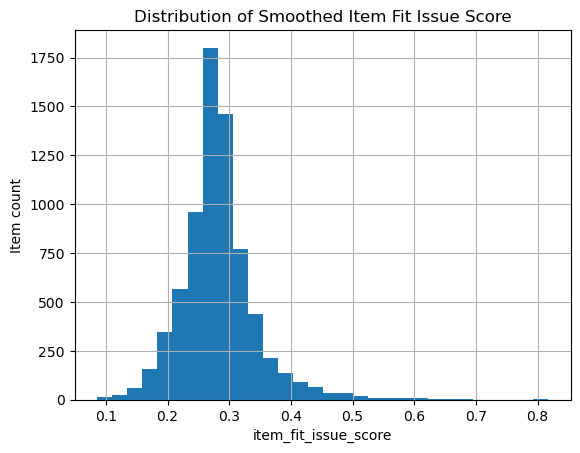

In [10]:
ax = fit_signals["item_fit_issue_score"].hist(bins=30)
ax.set_title("Distribution of Smoothed Item Fit Issue Score")
ax.set_xlabel("item_fit_issue_score")
ax.set_ylabel("Item count")
plt.show()


## 8. Consistency checks

These checks protect the assumptions used by the next notebooks.  
They are intentionally short and fail fast if the signal table is inconsistent.


In [11]:
for col in score_columns + reliability_columns:
    non_missing = fit_signals[col].dropna()
    assert non_missing.between(0, 1).all(), f"{col} is outside [0, 1]"

for alpha_name, alpha_value in {
    "ALPHA_FIT": ALPHA_FIT,
    "ALPHA_LENGTH": ALPHA_LENGTH,
    "ALPHA_REVIEW": ALPHA_REVIEW,
    "ALPHA_QUALITY": ALPHA_QUALITY,
}.items():
    if alpha_name == "ALPHA_REVIEW" and fit_signals["has_review_text"].sum() == 0:
        assert pd.isna(alpha_value), "ALPHA_REVIEW should be missing when no review text exists"
    else:
        assert pd.notna(alpha_value) and alpha_value > 0, f"{alpha_name} must be positive when signal exists"

unexpected_binary_reliability_cols = [
    col for col in fit_signals.columns
    if col.endswith("_reliable") or col.endswith("_signal_reliable")
]
assert not unexpected_binary_reliability_cols, unexpected_binary_reliability_cols

assert fit_signals[["source", "item_id"]].duplicated().sum() == 0, "Duplicate source-item rows detected"

required_export_columns = ["source", "item_id", "item_fit_issue_score", "fit_signal_reliability_weight"]
missing_export_columns = [col for col in required_export_columns if col not in fit_signals.columns]
assert not missing_export_columns, missing_export_columns

missing_signal_contracts = [
    ("length_signal_count", "item_length_issue_score", "length_signal_reliability_weight"),
    ("review_text_count", "review_size_signal_rate", "review_signal_reliability_weight"),
    ("review_text_count", "review_quality_signal_rate", "review_signal_reliability_weight"),
    ("quality_signal_count", "item_quality_issue_score", "quality_signal_reliability_weight"),
]

for count_col, score_col, reliability_col in missing_signal_contracts:
    missing_mask = fit_signals[count_col] == 0
    assert fit_signals.loc[missing_mask, score_col].isna().all(), f"{score_col} should be missing when {count_col}=0"
    assert fit_signals.loc[missing_mask, reliability_col].eq(0).all(), f"{reliability_col} should be 0 when {count_col}=0"

print("Consistency checks passed.")


Consistency checks passed.


## 9. Export

The exported file is an item-level signal table.

It is intended to feed:

```text
04_mock_cart_features.ipynb
```

It is not a row-level merge with UCI Online Retail users or transactions.


In [12]:
FIT_SIGNALS_OUTPUT_PATH = DATA_PROCESSED / "fit_signals.csv"

export_columns = [
    "source",
    "item_id",
    "category",
    "item_review_count",
    "unique_user_count",

    "fit_signal_count",
    "fit_issue_count",
    "too_small_count",
    "too_large_count",
    "raw_fit_issue_rate",
    "item_fit_issue_score",
    "fit_signal_reliability_weight",

    "length_signal_count",
    "raw_length_issue_rate",
    "item_length_issue_score",
    "length_signal_reliability_weight",

    "review_text_count",
    "raw_review_size_signal_rate",
    "review_size_signal_rate",
    "raw_review_quality_signal_rate",
    "review_quality_signal_rate",
    "review_signal_reliability_weight",

    "quality_signal_count",
    "raw_quality_issue_score",
    "item_quality_issue_score",
    "quality_signal_reliability_weight",

    "has_fit_signal",
    "has_length_signal",
    "has_review_text",
    "has_quality_signal",
    "top_fit_issue",
]

fit_signals[export_columns].to_csv(FIT_SIGNALS_OUTPUT_PATH, index=False)

print("Saved:", FIT_SIGNALS_OUTPUT_PATH)
print("Shape:", fit_signals[export_columns].shape)


Saved: C:\Users\monster\Desktop\returnshield-ai\data\processed\fit_signals.csv
Shape: (7228, 31)


## 10. Limitations

This notebook creates a signal layer, not a predictive model.

Main limitations:

- Fit feedback is observed after purchase/rental and is used as a proxy for size/fit uncertainty.
- Keyword-based review signals are simple PoC signals and do not fully model negation or context.
- If an item or dataset version has no review text, review-derived scores are not generated; `has_review_text = 0` marks that absence.
- ModCloth and RentTheRunway may represent different shopping behaviors; the `source` column is retained.
- The output is not merged row-by-row with UCI Online Retail users or transactions.
- Low-coverage items with evidence are smoothed and represented with continuous reliability weights rather than arbitrary binary thresholds.
- The smoothing prior is data-derived from item coverage, so tiny test samples can produce unstable-looking rates; full data should be used for final interpretation.
- The generated signals are intended for explanation and ranking support in later agent notebooks, not as standalone causal evidence of returns.
